# Perf Comparison Notebook

This notebook analyzes the `perf_compare_1q.sh` output, merges the microarchitectural counters with the application-level reflect summaries, and highlights where the comparison is valid or misleading.

Important note: this notebook treats `perf stat` counters as **counter hotspots**. For true symbol/function hotspots, you still need `perf record` / `perf report`.

In [8]:
from pathlib import Path
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
plt.style.use("seaborn-v0_8-whitegrid")

ROOT_CANDIDATES = [Path.cwd(), Path('/users/manvik12/my_ice')]
ROOT = next((p for p in ROOT_CANDIDATES if (p / 'results' / 'perf_compare_1q').exists()), ROOT_CANDIDATES[-1])
RESULTS_ROOT = ROOT / 'results' / 'perf_compare_1q'
RUN_DIRS = sorted([p for p in RESULTS_ROOT.iterdir() if p.is_dir()])
if not RUN_DIRS:
    raise FileNotFoundError(f'No perf_compare_1q results found under {RESULTS_ROOT}')

# Change this manually if you want a different run than the newest one.
RUN_DIR = RUN_DIRS[-1]
RAW_CSV = RUN_DIR / 'raw_perf.csv'
SUMMARY_CSV = RUN_DIR / 'summary.csv'
METADATA_FILE = RUN_DIR / 'metadata.txt'
RUNS_DIR = RUN_DIR / 'runs'

print(f'Project root : {ROOT}')
print(f'Run directory : {RUN_DIR}')
print(f'Raw CSV       : {RAW_CSV.name}')
print(f'Summary CSV   : {SUMMARY_CSV.name}')

Project root : /users/manvik12/my_ice
Run directory : /users/manvik12/my_ice/results/perf_compare_1q/20260506_012956
Raw CSV       : raw_perf.csv
Summary CSV   : summary.csv


## Load Raw Perf Data

The script's `summary.csv` is convenient, but the most reliable source is `raw_perf.csv`, because it preserves every event as recorded by `perf stat`. We rebuild the run-level table from the raw file so the notebook stays robust even if the summary format changes.

In [9]:
def load_metadata(path: Path) -> dict:
    meta = {}
    if path.exists():
        for line in path.read_text().splitlines():
            if '=' in line:
                k, v = line.split('=', 1)
                meta[k.strip()] = v.strip()
    return meta

metadata = load_metadata(METADATA_FILE)
raw = pd.read_csv(RAW_CSV)

for col in ['value', 'raw_runtime', 'pct_running', 'metric_value']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

display(pd.DataFrame([metadata]).T.rename(columns={0: 'value'}))
raw.head(10)

,value
timestamp_utc,2026-05-06T01:29:56Z
hostname,node0.e810.redshift-pg0.utah.cloudlab.us
kernel,5.15.0-168-generic
bdf,0000:17:00.0
duration_seconds,30
runs,1
c_binary,/users/manvik12/my_ice/my_ice
rust_binary,/users/manvik12/my_ice_rust/target/release/my_...
c_tx_batch_size,64
reflect_batch_size,64


,timestamp_utc,run_id,impl,source,event,value,unit,raw_runtime,pct_running,metric_value,metric_unit,status
0,2026-05-06T01:29:56Z,c_run01,c,time,wall_seconds,3.136000e+01,seconds,NaN,NaN,NaN,ok,NaN
1,2026-05-06T01:29:56Z,c_run01,c,time,user_seconds,2.935000e+01,seconds,NaN,NaN,NaN,ok,NaN
2,2026-05-06T01:29:56Z,c_run01,c,time,sys_seconds,1.000000e-02,seconds,NaN,NaN,NaN,ok,NaN
3,2026-05-06T01:29:56Z,c_run01,c,time,max_rss_kb,1.620800e+04,kB,NaN,NaN,NaN,ok,NaN
4,2026-05-06T01:29:56Z,c_run01,c,perf,instructions,1.556846e+11,NaN,4.382259e+09,14.96,1.780,insn per cycle,ok
5,2026-05-06T01:29:56Z,c_run01,c,perf,cycles,8.749878e+10,NaN,5.846259e+09,19.95,2.988,GHz,ok
6,2026-05-06T01:29:56Z,c_run01,c,perf,ref-cycles,6.144113e+10,NaN,7.310270e+09,24.95,2.098,G/sec,ok
7,2026-05-06T01:29:56Z,c_run01,c,perf,task-clock,2.928819e+04,msec,2.928819e+10,100.00,0.936,CPUs utilized,ok
8,2026-05-06T01:29:56Z,c_run01,c,perf,cpu-clock,2.928725e+04,msec,2.928819e+10,100.00,0.936,CPUs utilized,ok
9,2026-05-06T01:29:56Z,c_run01,c,perf,context-switches,1.035000e+04,NaN,2.928819e+10,100.00,353.390,/sec,ok


In [10]:
time_wide = (
    raw.query("source == 'time'")
       .pivot_table(index=['run_id', 'impl'], columns='event', values='value', aggfunc='first')
)

perf_wide = (
    raw.query("source == 'perf'")
       .pivot_table(index=['run_id', 'impl'], columns='event', values='value', aggfunc='first')
)

status_counts = (
    raw.query("source == 'perf'")
       .groupby(['run_id', 'impl', 'status'])
       .size()
       .unstack(fill_value=0)
)

runs = time_wide.join(perf_wide, how='outer').join(status_counts, how='left').reset_index()
runs.columns = [c.replace('-', '_') if isinstance(c, str) else c for c in runs.columns]
runs['ipc_calc'] = runs['instructions'] / runs['cycles']
runs['cache_miss_pct_calc'] = 100.0 * runs['cache_misses'] / runs['cache_references']
runs['branch_miss_pct_calc'] = 100.0 * runs['branch_misses'] / runs['branches']
runs['L1_dcache_miss_pct_calc'] = 100.0 * runs['L1_dcache_load_misses'] / runs['L1_dcache_loads']
runs['dTLB_load_miss_pct_calc'] = 100.0 * runs['dTLB_load_misses'] / runs['dTLB_loads']

key_cols = [
    'run_id', 'impl', 'wall_seconds', 'user_seconds', 'sys_seconds', 'instructions', 'cycles', 'ipc_calc',
    'context_switches', 'branches', 'branch_misses', 'cache_references', 'cache_misses',
    'L1_dcache_load_misses', 'L1_icache_load_misses', 'LLC_load_misses', 'LLC_store_misses', 'iTLB_load_misses'
]
runs[key_cols]

,run_id,impl,wall_seconds,user_seconds,sys_seconds,instructions,cycles,ipc_calc,context_switches,branches,branch_misses,cache_references,cache_misses,L1_dcache_load_misses,L1_icache_load_misses,LLC_load_misses,LLC_store_misses,iTLB_load_misses
0,c_run01,c,31.36,29.35,0.01,1.556846e+11,8.749878e+10,1.779278,10350.0,1.830042e+10,5297771.0,1.345146e+09,107417.0,326318153.0,2027391.0,8719.0,391.0,614613.0
1,rust_run01,rust,31.34,30.12,0.01,3.744419e+11,8.930051e+10,4.193055,9713.0,5.638039e+10,6115252.0,8.178380e+05,456732.0,959103.0,7083666.0,55.0,0.0,7691.0


## Parse Application-Level Throughput Logs

The perf counters alone do not tell us whether the reflector actually forwarded traffic. We therefore parse the per-run logs from `runs/*/stdout.log` and `runs/*/stderr.log` and merge in throughput, packet counts, doorbells, polling behavior, and queue stats.

In [11]:
def read_text(path: Path) -> str:
    return path.read_text(errors='replace') if path.exists() else ''

def to_number(d: dict) -> dict:
    out = {}
    for k, v in d.items():
        if re.fullmatch(r'-?\d+', v):
            out[k] = int(v)
        else:
            out[k] = float(v)
    return out

def parse_c_logs(text: str) -> dict:
    m = re.search(
        r"rx-reflect done: seconds=(?P<seconds>[\d.]+) "
        r"TX=(?P<tx_wire_gbps>[\d.]+) wire-Gbps "
        r"RX=(?P<rx_wire_gbps>[\d.]+) wire-Gbps "
        r"tx_mpps=(?P<tx_mpps>[\d.]+) rx_mpps=(?P<rx_mpps>[\d.]+) "
        r"tx_l2_gbps=(?P<tx_l2_gbps>[\d.]+) rx_l2_gbps=(?P<rx_l2_gbps>[\d.]+) "
        r"rx_pkts=(?P<rx_pkts>\d+) rx_bytes=(?P<rx_bytes>\d+) "
        r"tx_pkts=(?P<tx_pkts>\d+) tx_bytes=(?P<tx_bytes>\d+) "
        r"zero_copy_pkts=(?P<zero_copy_pkts>\d+) zero_copy_bytes=(?P<zero_copy_bytes>\d+) "
        r"tx_ring_full=(?P<tx_ring_full>\d+) rx_short=(?P<rx_short>\d+) rx_errors=(?P<rx_errors>\d+) "
        r"pool_empty=(?P<pool_empty>\d+) doorbells=(?P<doorbells>\d+) .*?GORC_delta=(?P<gorc_delta>\d+) GOTC_delta=(?P<gotc_delta>\d+)",
        text,
    )
    return to_number(m.groupdict()) if m else {}

def parse_rust_logs(text: str) -> dict:
    out = {}
    patterns = {
        'timing': r"active=(?P<active_seconds>[\d.]+)s\s+join=(?P<join_seconds>[\d.]+)s\s+drain=(?P<drain_seconds>[\d.]+)s\s+total=(?P<total_seconds>[\d.]+)s",
        'sw': r"sw:\s+rx\s+(?P<rx_wire_gbps>[\d.]+)\s+Gbps\s+tx\s+(?P<tx_wire_gbps>[\d.]+)\s+Gbps\s+(?P<tx_mpps>[\d.]+)\s+Mpps\s+(?P<ns_per_pkt>[\d.]+)\s+ns/pkt",
        'packets': r"total:\s+rx\s+(?P<rx_pkts>\d+)\s+pkts\s+\((?P<rx_bytes>\d+)\s+bytes\)\s+tx\s+(?P<tx_pkts>\d+)\s+pkts\s+\((?P<tx_bytes>\d+)\s+bytes\)",
        'ring': r"tx_ring_full=(?P<tx_ring_full>\d+)\s+rx_short=(?P<rx_short>\d+)",
        'mmio': r"doorbells=(?P<doorbells>\d+)\s+tail_advances=(?P<tail_advances>\d+)\s+total_mmio_writes=(?P<total_mmio_writes>\d+)\s+mmio/sec=(?P<mmio_per_sec>[\d.]+)",
        'batch': r"avg_pkts_per_doorbell=(?P<avg_pkts_per_doorbell>[\d.]+)\s+pkts_per_mmio_write=(?P<pkts_per_mmio_write>[\d.]+)",
        'poll': r"total_iterations=(?P<total_iterations>\d+)\s+empty_polls=(?P<empty_polls>\d+)\s+\((?P<empty_poll_pct>[\d.]+)%\)",
        'reclaim': r"reclaim_calls=(?P<reclaim_calls>\d+)\s+avg_pending_rearm_depth=(?P<avg_pending_rearm_depth>[\d.]+)",
        'port': r"port:\s+GORC=(?P<port_gorc>\d+)\s+\((?P<port_rx_gbps>[\d.]+)\s+Gbps\)\s+GOTC=(?P<port_gotc>\d+)\s+\((?P<port_tx_gbps>[\d.]+)\s+Gbps\)",
    }
    for pattern in patterns.values():
        m = re.search(pattern, text)
        if m:
            out.update(to_number(m.groupdict()))
    if 'tx_mpps' in out and 'rx_mpps' not in out:
        out['rx_mpps'] = out['tx_mpps']
    return out

log_rows = []
for run_dir in sorted([p for p in RUNS_DIR.iterdir() if p.is_dir()]):
    run_id = run_dir.name
    impl = 'rust' if run_id.startswith('rust') else 'c'
    stdout_text = read_text(run_dir / 'stdout.log')
    stderr_text = read_text(run_dir / 'stderr.log')
    parsed = parse_rust_logs(stdout_text) if impl == 'rust' else parse_c_logs(stderr_text)
    parsed.update({'run_id': run_id, 'impl': impl})
    log_rows.append(parsed)

app = pd.DataFrame(log_rows)
app

,seconds,tx_wire_gbps,rx_wire_gbps,tx_mpps,rx_mpps,tx_l2_gbps,rx_l2_gbps,rx_pkts,rx_bytes,tx_pkts,tx_bytes,zero_copy_pkts,zero_copy_bytes,tx_ring_full,rx_short,rx_errors,pool_empty,doorbells,gorc_delta,gotc_delta,run_id,impl,active_seconds,join_seconds,drain_seconds,total_seconds,ns_per_pkt,tail_advances,total_mmio_writes,mmio_per_sec,avg_pkts_per_doorbell,pkts_per_mmio_write,total_iterations,empty_polls,empty_poll_pct,reclaim_calls,avg_pending_rearm_depth,port_gorc,port_rx_gbps,port_gotc,port_tx_gbps
0,29.26,16.468,16.468,24.506,24.506,11.763,11.763,717041848,43022510880,717041848,43022510880,717041848.0,4.302251e+10,0,0,0.0,0.0,11203779,1.810260e+11,4.302251e+10,c_run01,c,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,0.000,0.000,0.000,0.000,NaN,NaN,0,0,0,0,NaN,NaN,0,0,NaN,NaN,0,NaN,NaN,rust_run01,rust,30.018,0.0,1.0,31.018,0.0,0.0,0.0,0.0,0.0,0.0,5.683000e+09,5.683000e+09,100.0,0.0,0.0,366.0,0.0,0.0,0.0


In [12]:
analysis = runs.merge(app, on=['run_id', 'impl'], how='left')

analysis['instructions_per_sec'] = analysis['instructions'] / analysis['wall_seconds']
analysis['cycles_per_sec'] = analysis['cycles'] / analysis['wall_seconds']
analysis['instructions_per_pkt'] = analysis['instructions'] / analysis['tx_pkts']
analysis['cycles_per_pkt'] = analysis['cycles'] / analysis['tx_pkts']
analysis['branches_per_pkt'] = analysis['branches'] / analysis['tx_pkts']
analysis['doorbells_per_mpkt'] = 1e6 * analysis['doorbells'] / analysis['tx_pkts']

cols = [
    'run_id', 'impl', 'wall_seconds', 'instructions', 'cycles', 'ipc_calc',
    'context_switches', 'L1_dcache_load_misses', 'L1_icache_load_misses', 'iTLB_load_misses',
    'LLC_load_misses', 'LLC_store_misses', 'rx_pkts', 'tx_pkts', 'rx_wire_gbps', 'tx_wire_gbps',
    'doorbells', 'empty_polls', 'total_iterations', 'instructions_per_pkt', 'cycles_per_pkt', 'doorbells_per_mpkt'
]
analysis[cols]

,run_id,impl,wall_seconds,instructions,cycles,ipc_calc,context_switches,L1_dcache_load_misses,L1_icache_load_misses,iTLB_load_misses,LLC_load_misses,LLC_store_misses,rx_pkts,tx_pkts,rx_wire_gbps,tx_wire_gbps,doorbells,empty_polls,total_iterations,instructions_per_pkt,cycles_per_pkt,doorbells_per_mpkt
0,c_run01,c,31.36,1.556846e+11,8.749878e+10,1.779278,10350.0,326318153.0,2027391.0,614613.0,8719.0,391.0,717041848,717041848,16.468,16.468,11203779,NaN,NaN,217.120687,122.027445,15625.000174
1,rust_run01,rust,31.34,3.744419e+11,8.930051e+10,4.193055,9713.0,959103.0,7083666.0,7691.0,55.0,0.0,0,0,0.000,0.000,0,5.683000e+09,5.683000e+09,inf,inf,NaN


## Data Quality And Fairness Checks

Before interpreting ratios, we should confirm whether both runs actually reflected traffic. If one side processed zero packets, then the perf counters mostly describe idle polling and setup overhead rather than the dataplane.

In [13]:
issues = []

for _, row in analysis.iterrows():
    if pd.notna(row.get('tx_pkts')) and row['tx_pkts'] == 0:
        issues.append(f"{row['run_id']} ({row['impl']}) transmitted 0 packets. Its perf counters describe idle polling / setup, not successful forwarding.")
    if pd.notna(row.get('rx_wire_gbps')) and row['rx_wire_gbps'] == 0:
        issues.append(f"{row['run_id']} ({row['impl']}) shows 0.000 Gbps in the application summary.")

unsupported = (
    raw.query("source == 'perf' and status != 'ok'")
       .groupby(['impl', 'event', 'status'])
       .size()
       .reset_index(name='count')
)

if issues:
    display(Markdown('### Findings\n' + '\n'.join(f'- {x}' for x in issues)))
else:
    display(Markdown('### Findings\n- No obvious data-quality blockers found.'))

display(Markdown('### Unsupported / not-counted events'))
unsupported

### Findings
- rust_run01 (rust) transmitted 0 packets. Its perf counters describe idle polling / setup, not successful forwarding.
- rust_run01 (rust) shows 0.000 Gbps in the application summary.

### Unsupported / not-counted events

,impl,event,status,count
0,c,L1-icache-loads,<not supported>,1
1,c,iTLB-loads,<not supported>,1
2,c,stalled-cycles-backend,<not supported>,1
3,c,stalled-cycles-frontend,<not supported>,1
4,rust,L1-icache-loads,<not supported>,1
5,rust,iTLB-loads,<not supported>,1
6,rust,stalled-cycles-backend,<not supported>,1
7,rust,stalled-cycles-frontend,<not supported>,1


## Aggregate By Implementation

If you have multiple runs, this section averages them. With one run each, it simply gives a clean C-vs-Rust summary.

In [14]:
numeric_cols = analysis.select_dtypes(include='number').columns
agg = analysis.groupby('impl')[numeric_cols].mean(numeric_only=True)
agg[['wall_seconds', 'user_seconds', 'sys_seconds', 'instructions', 'cycles', 'ipc_calc', 'tx_pkts', 'rx_wire_gbps', 'context_switches']]

,wall_seconds,user_seconds,sys_seconds,instructions,cycles,ipc_calc,tx_pkts,rx_wire_gbps,context_switches
impl,,,,,,,,,
c,31.36,29.35,0.01,1.556846e+11,8.749878e+10,1.779278,717041848.0,16.468,10350.0
rust,31.34,30.12,0.01,3.744419e+11,8.930051e+10,4.193055,0.0,0.000,9713.0


In [15]:
def build_compare_table(metrics):
    rows = []
    if not {'c', 'rust'}.issubset(agg.index):
        return pd.DataFrame()
    for metric in metrics:
        c_val = agg.loc['c', metric] if metric in agg.columns else np.nan
        r_val = agg.loc['rust', metric] if metric in agg.columns else np.nan
        ratio = np.nan
        if pd.notna(c_val) and c_val != 0 and pd.notna(r_val):
            ratio = r_val / c_val
        rows.append({
            'metric': metric,
            'c': c_val,
            'rust': r_val,
            'rust_over_c': ratio,
            'pct_delta': (ratio - 1.0) * 100 if pd.notna(ratio) else np.nan,
        })
    return pd.DataFrame(rows)

compare_metrics = [
    'tx_pkts', 'rx_wire_gbps', 'instructions', 'cycles', 'ipc_calc',
    'context_switches', 'user_seconds', 'sys_seconds',
    'branches', 'branch_misses', 'L1_dcache_load_misses', 'L1_icache_load_misses',
    'LLC_load_misses', 'LLC_store_misses', 'iTLB_load_misses',
    'instructions_per_pkt', 'cycles_per_pkt', 'doorbells'
]

compare_df = build_compare_table(compare_metrics)
compare_df

,metric,c,rust,rust_over_c,pct_delta
0,tx_pkts,7.170418e+08,0.000000e+00,0.000000,-100.000000
1,rx_wire_gbps,1.646800e+01,0.000000e+00,0.000000,-100.000000
2,instructions,1.556846e+11,3.744419e+11,2.405131,140.513094
3,cycles,8.749878e+10,8.930051e+10,1.020591,2.059139
4,ipc_calc,1.779278e+00,4.193055e+00,2.356605,135.660515
5,context_switches,1.035000e+04,9.713000e+03,0.938454,-6.154589
6,user_seconds,2.935000e+01,3.012000e+01,1.026235,2.623509
7,sys_seconds,1.000000e-02,1.000000e-02,1.000000,0.000000
8,branches,1.830042e+10,5.638039e+10,3.080824,208.082402
9,branch_misses,5.297771e+06,6.115252e+06,1.154307,15.430659


## Visual Comparison

These charts separate application throughput from low-level counters. When throughput is zero for one side, interpret the rest as a control-path / polling profile rather than a reflect datapath profile.

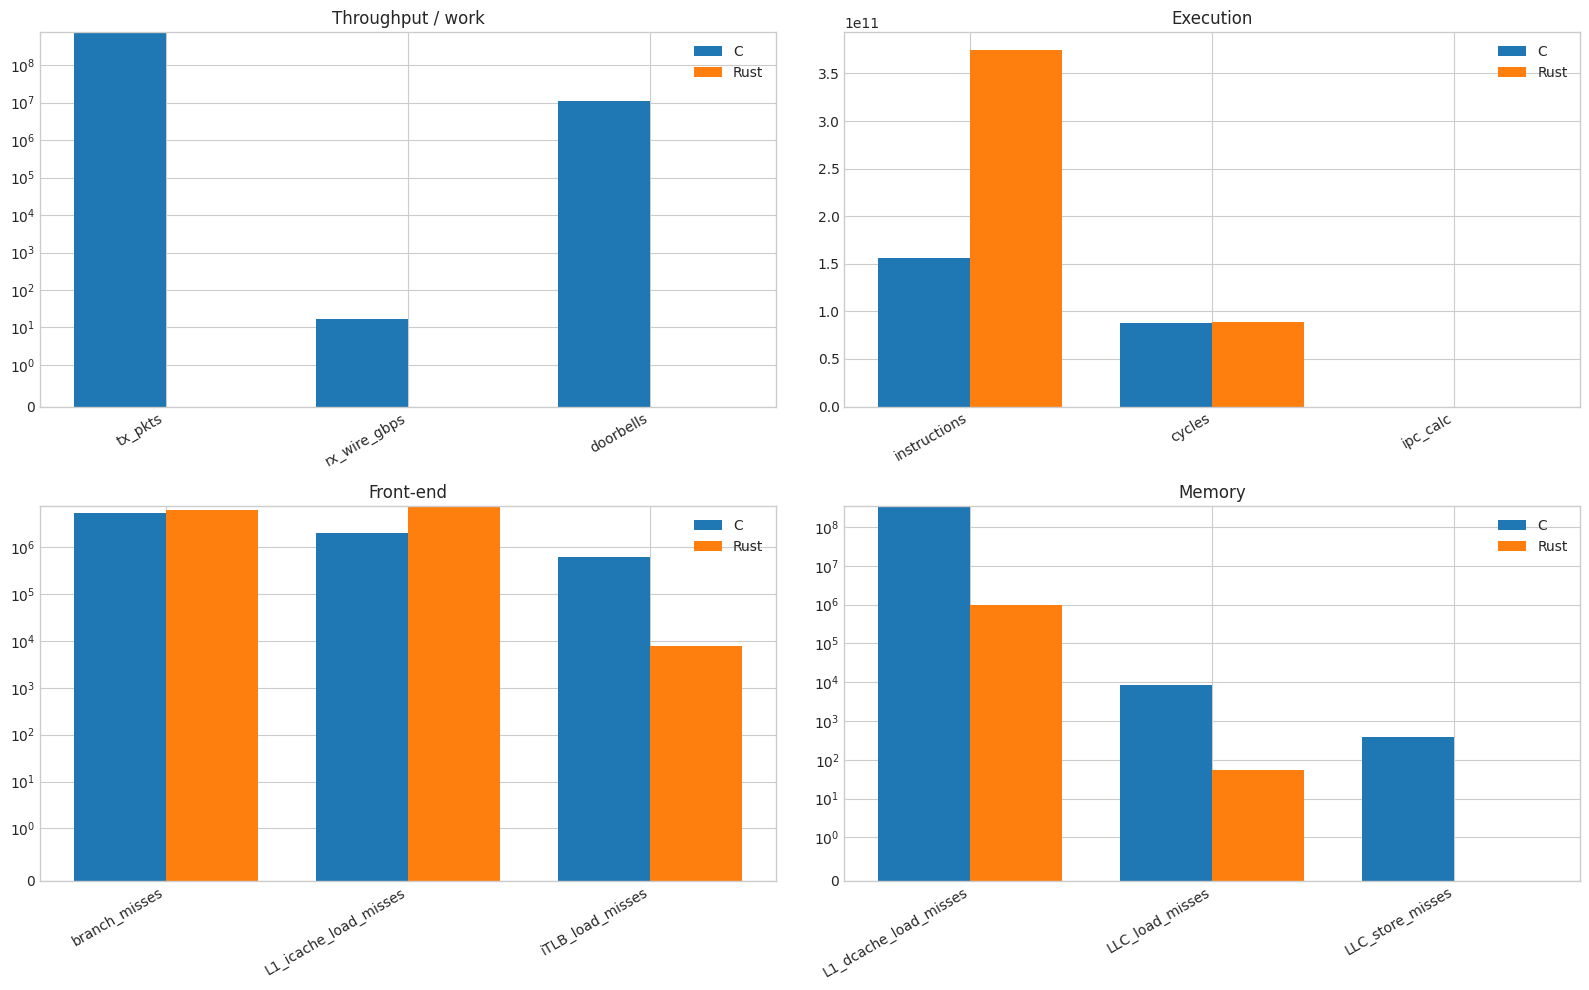

In [16]:
plot_metrics = {
    'Throughput / work': ['tx_pkts', 'rx_wire_gbps', 'doorbells'],
    'Execution': ['instructions', 'cycles', 'ipc_calc'],
    'Front-end': ['L1_icache_load_misses', 'iTLB_load_misses', 'branch_misses'],
    'Memory': ['L1_dcache_load_misses', 'LLC_load_misses', 'LLC_store_misses'],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, (title, metrics) in zip(axes, plot_metrics.items()):
    subset = compare_df[compare_df['metric'].isin(metrics)].copy()
    if subset.empty:
        ax.set_visible(False)
        continue
    x = np.arange(len(subset))
    width = 0.38
    ax.bar(x - width / 2, subset['c'], width=width, label='C')
    ax.bar(x + width / 2, subset['rust'], width=width, label='Rust')
    ax.set_xticks(x)
    ax.set_xticklabels(subset['metric'], rotation=30, ha='right')
    ax.set_title(title)
    if title != 'Execution':
        ax.set_yscale('symlog', linthresh=1)
    ax.legend()

plt.tight_layout()
plt.show()

## Counter Hotspots

This is not a function-level flame graph. Instead, it ranks counters by relative change (`rust / c`) so you can see which aspects of execution diverge most.

In [17]:
hotspot_candidates = [
    'instructions', 'cycles', 'branches', 'branch_misses',
    'L1_dcache_loads', 'L1_dcache_load_misses', 'L1_dcache_stores',
    'L1_icache_load_misses', 'dTLB_loads', 'dTLB_load_misses',
    'dTLB_stores', 'dTLB_store_misses', 'iTLB_load_misses',
    'LLC_loads', 'LLC_load_misses', 'LLC_stores', 'LLC_store_misses',
    'context_switches', 'page_faults', 'tx_pkts', 'rx_wire_gbps', 'doorbells',
    'instructions_per_pkt', 'cycles_per_pkt', 'doorbells_per_mpkt'
]

hotspots = build_compare_table([m for m in hotspot_candidates if m in agg.columns or m in analysis.columns])
hotspots = hotspots.replace([np.inf, -np.inf], np.nan)
hotspots.sort_values('rust_over_c', ascending=False).head(20)

,metric,c,rust,rust_over_c,pct_delta
7,L1_icache_load_misses,2.027391e+06,7.083666e+06,3.493981,249.398118
10,dTLB_stores,2.952754e+10,9.689447e+10,3.281495,228.149508
6,L1_dcache_stores,2.951714e+10,9.658290e+10,3.272095,227.209516
2,branches,1.830042e+10,5.638039e+10,3.080824,208.082402
8,dTLB_loads,3.730430e+10,9.728465e+10,2.607867,160.786661
4,L1_dcache_loads,3.728109e+10,9.647911e+10,2.587883,158.788312
0,instructions,1.556846e+11,3.744419e+11,2.405131,140.513094
3,branch_misses,5.297771e+06,6.115252e+06,1.154307,15.430659
1,cycles,8.749878e+10,8.930051e+10,1.020591,2.059139
9,dTLB_load_misses,8.650000e+02,8.800000e+02,1.017341,1.734104


In [18]:
def fmt(v, digits=3):
    if pd.isna(v):
        return 'n/a'
    if abs(v) >= 1e6:
        return f'{v:,.0f}'
    if abs(v) >= 1000:
        return f'{v:,.1f}'
    return f'{v:.{digits}f}'

notes = []

if {'c', 'rust'}.issubset(agg.index):
    c_tx = agg.loc['c', 'tx_pkts'] if 'tx_pkts' in agg.columns else np.nan
    r_tx = agg.loc['rust', 'tx_pkts'] if 'tx_pkts' in agg.columns else np.nan
    c_gbps = agg.loc['c', 'rx_wire_gbps'] if 'rx_wire_gbps' in agg.columns else np.nan
    r_gbps = agg.loc['rust', 'rx_wire_gbps'] if 'rx_wire_gbps' in agg.columns else np.nan
    c_ipc = agg.loc['c', 'ipc_calc'] if 'ipc_calc' in agg.columns else np.nan
    r_ipc = agg.loc['rust', 'ipc_calc'] if 'ipc_calc' in agg.columns else np.nan
    c_instr = agg.loc['c', 'instructions'] if 'instructions' in agg.columns else np.nan
    r_instr = agg.loc['rust', 'instructions'] if 'instructions' in agg.columns else np.nan
    c_cs = agg.loc['c', 'context_switches'] if 'context_switches' in agg.columns else np.nan
    r_cs = agg.loc['rust', 'context_switches'] if 'context_switches' in agg.columns else np.nan

    if pd.notna(r_tx) and r_tx == 0 and pd.notna(c_tx) and c_tx > 0:
        notes.append(
            f'Rust forwarded 0 packets while C forwarded {fmt(c_tx, 0)} packets. This means the current perf comparison is not apples-to-apples: Rust mostly measured empty polling, while C measured an active reflect dataplane.'
        )
    else:
        notes.append(
            f'C throughput was {fmt(c_gbps)} Gbps vs Rust {fmt(r_gbps)} Gbps, with IPC {fmt(c_ipc)} vs {fmt(r_ipc)} and instructions {fmt(c_instr)} vs {fmt(r_instr)}.'
        )

    notes.append(
        f'Context switches were C={fmt(c_cs, 0)} vs Rust={fmt(r_cs, 0)}. If throughput is zero on one side, treat this as an idle-loop behavior difference rather than a dataplane efficiency result.'
    )

    top_nonzero = hotspots.dropna(subset=['rust_over_c']).query('metric != "tx_pkts" and metric != "rx_wire_gbps"').sort_values('rust_over_c', ascending=False).head(5)
    if not top_nonzero.empty:
        top_lines = [f"{row.metric}: rust/c={row.rust_over_c:.2f}x" for row in top_nonzero.itertuples()]
        notes.append('Largest relative counter deltas: ' + '; '.join(top_lines) + '.')

display(Markdown('## Notebook Takeaway\n' + '\n'.join(f'- {note}' for note in notes)))

## Notebook Takeaway
- Rust forwarded 0 packets while C forwarded 717,041,848 packets. This means the current perf comparison is not apples-to-apples: Rust mostly measured empty polling, while C measured an active reflect dataplane.
- Context switches were C=10,350.0 vs Rust=9,713.0. If throughput is zero on one side, treat this as an idle-loop behavior difference rather than a dataplane efficiency result.
- Largest relative counter deltas: L1_icache_load_misses: rust/c=3.49x; dTLB_stores: rust/c=3.28x; L1_dcache_stores: rust/c=3.27x; branches: rust/c=3.08x; dTLB_loads: rust/c=2.61x.

## If You Want True Function Hotspots Next

This notebook works from `perf stat`, so it explains **what kind of work** dominated the run. To learn **which functions** dominated the run, capture samples with something like:

```bash
sudo perf record -F 999 -g -- /users/manvik12/my_ice/my_ice <BDF> --rx-reflect 30 --rx-queues 1 --tx-batch-size 64 --rx-batch-size 64
sudo perf report
```

and similarly for Rust with the matching arguments. If you do that, we can extend this notebook or build a second one for sampled call-stack analysis.